# Clustering Using Spherical K-means

## Set up Environment

### Install Dependencies

In [1]:
!pip install --upgrade numpy pandas matplotlib wordcloud scikit-learn tqdm

^C


In [ ]:
!pip install --upgrade faiss-cpu

### Import Dependencies

In [2]:
import math
import os
import re
import faiss
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.manifold import TSNE

### Load Data

In [3]:
df = pd.read_pickle('datasets/tickets.pkl')

X_embeddings = np.vstack(df['EMBEDDING'].values)
embedding_dimension = X_embeddings.shape[1]

print("Vektor embedding berhasil dimuat kembali.")
print(f"Jumlah data: {X_embeddings.shape[0]}")
print(f"Dimensi embedding: {embedding_dimension}")

df.head()

Vektor embedding berhasil dimuat kembali.
Jumlah data: 1639
Dimensi embedding: 256


,RAW TICKET,CLEANED TICKET,NORMALIZED TICKET,EMBEDDING,WORDCLOUD TICKET
0,Klien: Setwapres Medsos\nisu: Crawlback Commen...,Crawlback Comment. Siang tim IT minta tolong b...,crawlback comment. sapaan tim it sapaan bantua...,"[0.00083771703, -0.58585614, 0.064690515, 0.08...",crawlback comment. bantuan crawlback comment m...
1,"selamat pagi tim it, mohon bantuannya saya men...","selamat pagi tim it, mohon bantuannya saya men...","sapaan tim it, sapaan saya menemukan link dari...","[0.02750907, 0.037827827, -0.5283966, -0.13133...",menemukan megapolitan.kompas.com tidak masuk d...
2,Klien: BPS\nIsu: Data postingan Instagram tida...,Data postingan Instagram tidak masuk. Selamat ...,data postingan instagram tidak masuk. sapaan t...,"[-0.17697816, -0.045605347, -0.3471804, 0.4249...",postingan instagram tidak masuk. apa bikin pos...
3,selamat sore mas @Dhanysybn dan tim info untuk...,selamat sore mas @Dhanysybn dan tim info untuk...,sapaan mas nama orang dan tim info untuk siput...,"[0.08603829, -0.017807081, 0.016980363, 0.3204...",siputri tidak bisa akses minta yaaa.
4,Klien: Heinz \nIsu: Dashboard loading\n\nSelam...,"Dashboard loading. Selamat sore tim IT, mohon ...","dashboard loading. sapaan tim it, sapaan ada k...","[0.14301413, 0.028007613, 0.030197145, 0.24381...",dashboard loading. keluhan pihak heinz dashboa...


## Experimenting

### Normalize Data

In [4]:
X_embeddings = np.ascontiguousarray(X_embeddings, dtype=np.float32)
faiss.normalize_L2(X_embeddings)

print("Vektor embedding berhasil dinormalisasi.")

Vektor embedding berhasil dinormalisasi.


### Initialize Spherical K-means

In [5]:
def run_skm(dimension, ncluster, X, niter=20):
    skm = faiss.Kmeans(
        d=dimension, 
        k=ncluster, 
        niter=niter, 
        verbose=True, 
        spherical=True
        )
    skm.train(X)

    centroids = skm.centroids
    _, labels = skm.index.search(X, 1)

    return centroids, labels.flatten()

In [6]:
def generate_wordclouds(texts_list, titles, save_path, main_title="", top_n=5):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    n_clouds = len(texts_list)
    top_words_per_cluster = []  # hasil yang dikembalikan
    
    if n_clouds == 0:
        return top_words_per_cluster
        
    cols = min(3, n_clouds)
    rows = math.ceil(n_clouds / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4.5))
    if main_title:
        fig.suptitle(main_title, fontsize=20, y=1.02)
        
    if n_clouds == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i in range(len(axes)):
        if i < n_clouds:
            combined_text = texts_list[i]
            if combined_text.strip():
                wc = WordCloud(
                    width=800, height=400,
                    background_color='white',
                    max_words=100,
                    collocations=False
                ).generate(combined_text)
                
                # Ekstrak top words dari objek wc yang sudah terbentuk
                word_freq = wc.process_text(combined_text)  # {kata: count_absolut}
                total = sum(word_freq.values())
                top_n_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
                top_words_per_cluster.append(
                    "; ".join(f"({word}, {count/total*100:.2f}%)" for word, count in top_n_words)
                )
                
                axes[i].imshow(wc, interpolation='bilinear')
            else:
                top_words_per_cluster.append("")
                axes[i].text(0.5, 0.5, 'Tidak ada teks', ha='center', va='center', fontsize=14)
                
            axes[i].set_title(titles[i], fontsize=16, pad=10)
            axes[i].axis('off')
        else:
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)
    
    return top_words_per_cluster  # list, panjang = n_clouds

In [7]:
def cosine_similarity_intra_cluster(embeddings, labels, centroids):
    centroids_norm = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
    sims = np.sum(embeddings * centroids_norm[labels], axis=1)
    return float(np.mean(sims))

### Run Experiments Scenario

In [ ]:
min_clusters = 2
max_clusters = 10
k_range = range(min_clusters, max_clusters + 1)

results = []
scenario_count = 0
wordcloud_texts = df['WORDCLOUD TICKET'].astype(str).values

total_iterations = sum(k1 * len(k_range) for k1 in k_range)

with tqdm(total=total_iterations, desc="Evaluasi + WordCloud") as pbar:
    
    for k1 in k_range:
        centroids_l1, labels_l1 = run_skm(embedding_dimension, k1, X_embeddings)
        silhouette_avg_l1 = silhouette_score(X_embeddings, labels_l1, metric='cosine')

        # Hitung n_output dan n_clustered untuk Level 1
        n_output_l1 = len(X_embeddings)
        n_clustered_l1 = np.sum(labels_l1 >= 0)

        # --- WordCloud Level 1 Gabungan ---
        l1_texts_list = []
        l1_titles = []
        cluster_texts_dict = {}
        
        for cluster_id in range(k1):
            cluster_indices = np.where(labels_l1 == cluster_id)[0]
            cluster_texts = wordcloud_texts[cluster_indices].tolist()
            cluster_texts_dict[cluster_id] = (cluster_embeddings:=X_embeddings[cluster_indices], cluster_texts, cluster_indices)
            
            l1_texts_list.append(" ".join(cluster_texts))
            l1_titles.append(f"Cluster L1 - {cluster_id + 1}")
            
        top_words_list_l1 = generate_wordclouds(
            l1_texts_list,
            l1_titles,
            f"results/wordclouds/k{k1}/L1_combined.png",
            main_title=f"Level 1 Wordclouds (k={k1})",
            top_n=3
        )

        # simpan label cluster L1
        labels_df_l1 = pd.DataFrame({
            'ticket': df['RAW TICKET'],
            'cluster_id': labels_l1 + 1  # 1-indexed
        })
        labels_dir_l1 = f"results/labels/k{k1}"
        os.makedirs(labels_dir_l1, exist_ok=True)
        labels_df_l1.to_csv(
            f"{labels_dir_l1}/labels.csv",
            index=False,
            encoding='utf-8',
            quoting=csv.QUOTE_ALL
        )

        for cluster_id in range(k1):
            cluster_embeddings, cluster_texts, cluster_indices = cluster_texts_dict[cluster_id]

            top_words_l1 = top_words_list_l1[cluster_id]

            for k2 in k_range:
                if len(cluster_embeddings) >= k2:
                    centroids_l2, labels_l2 = run_skm(embedding_dimension, k2, cluster_embeddings)
                    silhouette_avg_l2 = silhouette_score(cluster_embeddings, labels_l2, metric='cosine')

                    # Hitung n_output dan n_clustered untuk Level 2
                    n_output_l2 = len(cluster_embeddings)
                    n_clustered_l2 = np.sum(labels_l2 >= 0)

                    # --- WordCloud Level 2 Gabungan ---
                    l2_texts_list = []
                    l2_titles = []
                    
                    for sub_id in range(k2):
                        sub_indices = np.where(labels_l2 == sub_id)[0]
                        sub_texts = [cluster_texts[i] for i in sub_indices]

                        l2_texts_list.append(" ".join(sub_texts))
                        l2_titles.append(f"Sub-cluster L2 - {sub_id + 1}")

                    top_words_list_l2 = generate_wordclouds(
                        l2_texts_list,
                        l2_titles,
                        f"results/wordclouds/k{k1}/cluster_{cluster_id+1}_k{k2}/L2_combined.png",
                        main_title=f"Level 2: k={k2} (Berasal dari L1 Cluster {cluster_id + 1})",
                        top_n=3
                    )
                    # Susun format per sub-cluster
                    top_words_l2 = "; ".join(
                        f"(sub-cluster id, {sub_id + 1}; [{top_words_list_l2[sub_id]}])"
                        for sub_id in range(k2)
                    )

                    # --- Simpan Pemetaan Ticket -> Cluster (k1) & Sub-cluster (k2) ---
                    sub_cluster_ids = labels_l2 + 1  # 1-indexed agar konsisten dgn cluster_id

                    labels_df = pd.DataFrame({
                        'ticket': [df['RAW TICKET'].iloc[idx] for idx in cluster_indices],
                        'cluster_id': cluster_id + 1,
                        'sub_cluster_id': sub_cluster_ids
                    })

                    labels_dir = f"results/labels/k{k1}/cluster_{cluster_id+1}_k{k2}"
                    os.makedirs(labels_dir, exist_ok=True)
                    labels_df.to_csv(
                        f"{labels_dir}/labels.csv",
                        index=False,
                        encoding='utf-8',
                        quoting=csv.QUOTE_ALL
                    )

                    # --- Ending Conditions Check ---

                    # Objective Condition 1: semua input di L1 dan L2 berhasil diklastering
                    objective_condition_1 = "YES" if (n_clustered_l1 == n_output_l1 and n_clustered_l2 == n_output_l2) else "NO"

                    # Subjective Concise: k1 dan k2 berada dalam rentang [2, 10]
                    subjective_concise = "YES" if (2 <= k1 <= 10 and 2 <= k2 <= 10) else "NO"

                    # Subjective Robust: silhouette avg dalam [0, 0.5] DAN cosine similarity intra-cluster mendekati 1
                    cosine_sim_intra_l1 = cosine_similarity_intra_cluster(X_embeddings, labels_l1, centroids_l1)
                    cosine_sim_intra_l2 = cosine_similarity_intra_cluster(cluster_embeddings, labels_l2, centroids_l2)
                    COSINE_SIM_THRESHOLD = 0.75
                    is_silhouette_in_range = (0 <= silhouette_avg_l1 <= 0.5) and (0 <= silhouette_avg_l2 <= 0.5)
                    is_cosine_near_one = (cosine_sim_intra_l1 >= COSINE_SIM_THRESHOLD) and (cosine_sim_intra_l2 >= COSINE_SIM_THRESHOLD)
                    subjective_robust = "YES" if (is_silhouette_in_range and is_cosine_near_one) else "NO"

                    # Subjective Comprehensive: semua input di L1 dan L2 berhasil diklastering
                    subjective_comprehensive = "YES" if (n_clustered_l1 == n_output_l1 and n_clustered_l2 == n_output_l2) else "NO"

                    results.append({
                        'scenario_id': f"{k1-1}.{cluster_id+1}.{k2-1}",
                        'cluster_id': f"{k1}.{cluster_id+1}",
                        'k1': k1,
                        'k2': k2,
                        'silhouette_avg_l1': f"{silhouette_avg_l1:.4f}",
                        'silhouette_avg_l2': f"{silhouette_avg_l2:.4f}",
                        'cosine_sim_intra_l1': f"{cosine_sim_intra_l1:.4f}",
                        'cosine_sim_intra_l2': f"{cosine_sim_intra_l2:.4f}",
                        'n_output_l1': n_output_l1,
                        'n_clustered_l1': n_clustered_l1,
                        'n_output_l2': n_output_l2,
                        'n_clustered_l2': n_clustered_l2,
                        'objective_condition_1': objective_condition_1,
                        'subjective_concise': subjective_concise,
                        'subjective_robust': subjective_robust,
                        'subjective_comprehensive': subjective_comprehensive,
                        'top_words_l1': top_words_l1,
                        'top_words_l2': top_words_l2
                    })
                    scenario_count += 1
                
                pbar.update(1)

print(f"\nTotal scenario yang berhasil dievaluasi: {scenario_count}")
print("Semua gambar WordCloud telah digabung dan disimpan di results/wordclouds/")

Evaluasi + WordCloud:   5%|▌         | 26/486 [03:45<1:24:04, 10.97s/it]WARNING: Connection timed out while downloading.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\najib\\miniconda3\\envs\\ta_510_taxodev\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



  Using cached numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----------

Evaluasi + WordCloud:  29%|██▉       | 142/486 [20:14<47:26,  8.28s/it]  

In [ ]:
# ===== Ending Condition: Subjective Extendible =====
# Terpenuhi jika silhouette_avg_l1 adalah BEST untuk tingkat 1 tersebut
# DAN silhouette_avg_l2 adalah BEST di antara semua k2 untuk cluster_id (L1) yang sama.

results_df_temp = pd.DataFrame(results)
results_df_temp['silhouette_avg_l1'] = results_df_temp['silhouette_avg_l1'].astype(float)
results_df_temp['silhouette_avg_l2'] = results_df_temp['silhouette_avg_l2'].astype(float)

# Best silhouette L1 untuk setiap k1
best_sil_l1 = results_df_temp['silhouette_avg_l1'].max()

# Best silhouette L2 untuk setiap cluster_id (kombinasi k1 + cluster L1 tertentu)
best_sil_l2_per_cluster = results_df_temp.groupby('cluster_id')['silhouette_avg_l2'].max()

for r in results:
    k1_val = r['k1']
    cluster_id_val = r['cluster_id']
    sil_l1_val = float(r['silhouette_avg_l1'])
    sil_l2_val = float(r['silhouette_avg_l2'])

    is_best_l1 = (sil_l1_val == best_sil_l1)
    is_best_l2 = (sil_l2_val == best_sil_l2_per_cluster[cluster_id_val])

    r['subjective_extendible'] = "YES" if (is_best_l1 and is_best_l2) else "NO"

print("Kolom 'subjective_extendible' berhasil ditambahkan ke seluruh hasil skenario.")

Kolom 'subjective_extendible' berhasil ditambahkan ke seluruh hasil skenario.


In [ ]:
file_path = 'results/experiments/results.csv'
os.makedirs(os.path.dirname(file_path), exist_ok=True)

if results:
    fieldnames = list(results[0].keys())
    
    with open(file_path, 'w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames, quoting=csv.QUOTE_ALL)
        
        writer.writeheader()
        writer.writerows(results)
    
    print(f"Results saved to {file_path}")

Results saved to results/experiments/results.csv


: 

## Visualisasi t-SNE

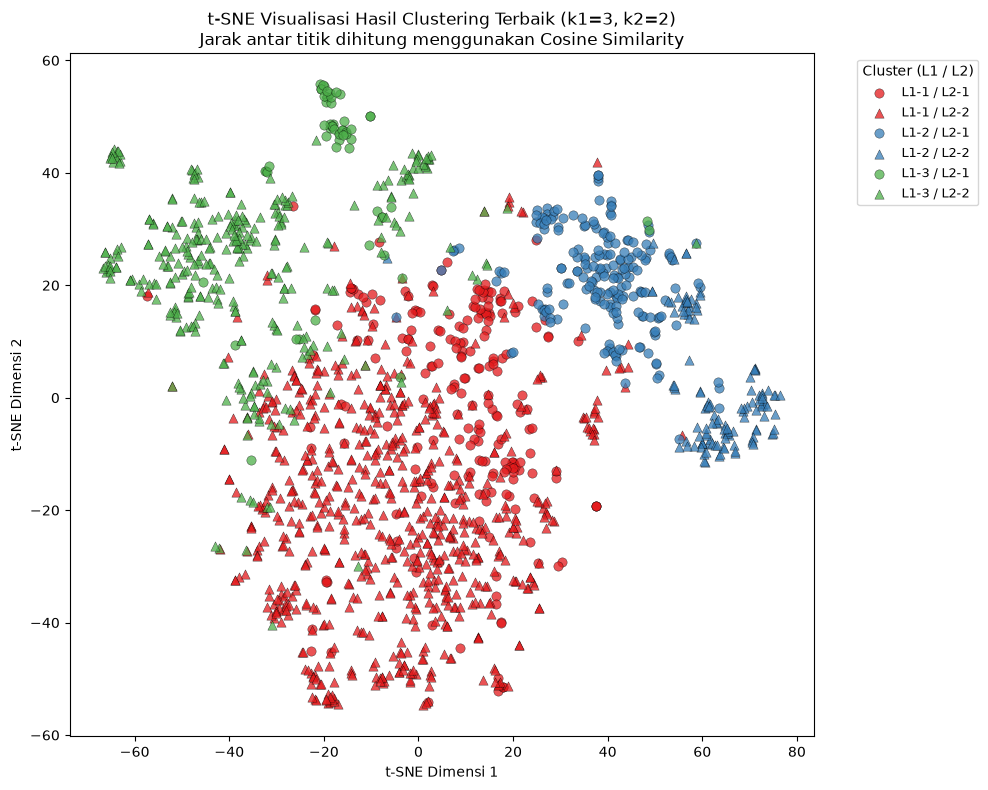

Visualisasi t-SNE disimpan di results/tsne/k3_k2_tsne.png


In [ ]:
BEST_K1 = 3
BEST_K2 = 2

# --- Load label Level 1 ---
labels_l1_path = f"results/labels/k{BEST_K1}/labels.csv"
labels_df_l1_best = pd.read_csv(labels_l1_path)

assert len(labels_df_l1_best) == len(df), (
    "Jumlah baris L1 CSV tidak cocok dengan df. "
    "Pastikan df yang dimuat sama dengan saat experiment loop dijalankan (urutan tiket tidak berubah)."
)

cluster_id_l1_arr = labels_df_l1_best['cluster_id'].to_numpy()

# --- Load label Level 2 tiap cluster L1, lalu gabungkan sesuai urutan asli df ---
sub_cluster_id_arr = np.full(len(df), np.nan)

for cid in range(1, BEST_K1 + 1):
    l2_path = f"results/labels/k{BEST_K1}/cluster_{cid}_k{BEST_K2}/labels.csv"
    labels_df_l2 = pd.read_csv(l2_path)

    # Baris L2 CSV mengikuti urutan np.where(cluster_id_l1_arr == cid)[0] (ascending)
    # sesuai cara cluster_indices dibentuk pada experiment loop
    original_idx = np.where(cluster_id_l1_arr == cid)[0]

    assert len(original_idx) == len(labels_df_l2), (
        f"Jumlah baris L2 CSV untuk cluster L1={cid} tidak cocok dengan jumlah anggota cluster tersebut di L1 CSV."
    )

    sub_cluster_id_arr[original_idx] = labels_df_l2['sub_cluster_id'].to_numpy()

assert not np.isnan(sub_cluster_id_arr).any(), "Ada tiket yang tidak mendapat sub_cluster_id (L2)."

# --- t-SNE, jarak dihitung dengan cosine similarity ---
perplexity = min(30, max(5, len(df) // 100))

tsne = TSNE(
    n_components=2,
    metric='cosine',
    perplexity=perplexity,
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_embeddings)

# --- Plot ---
markers = ['o', '^', 's', 'D', 'P', 'X']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#a65628']

fig, ax = plt.subplots(figsize=(10, 8))

for cid in range(1, BEST_K1 + 1):
    for sub_id in range(1, BEST_K2 + 1):
        mask = (cluster_id_l1_arr == cid) & (sub_cluster_id_arr == sub_id)
        ax.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            c=[colors[cid - 1]],
            marker=markers[(sub_id - 1) % len(markers)],
            label=f"L1-{cid} / L2-{sub_id}",
            alpha=0.75,
            s=45,
            edgecolors='k',
            linewidths=0.3
        )

ax.set_title(
    f"t-SNE Visualisasi Hasil Clustering Terbaik (k1={BEST_K1}, k2={BEST_K2})\n"
    "Jarak antar titik dihitung menggunakan Cosine Similarity"
)
ax.set_xlabel("t-SNE Dimensi 1")
ax.set_ylabel("t-SNE Dimensi 2")
ax.legend(title="Cluster (L1 / L2)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()

save_path = f"results/tsne/k{BEST_K1}_k{BEST_K2}_tsne.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"Visualisasi t-SNE disimpan di {save_path}")

## Extraksi Centroid dan 10 Data tiket representatif

In [ ]:
def compute_spherical_centroid(embeddings):
    """
    Menghitung centroid ala spherical k-means: rata-rata vektor anggota cluster,
    kemudian dinormalisasi (L2) agar berada pada unit hypersphere yang sama
    dengan X_embeddings (konsisten dengan cosine_similarity_intra_cluster()).
    """
    mean_vec = embeddings.mean(axis=0, keepdims=True)
    norm = np.linalg.norm(mean_vec, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    return (mean_vec / norm).flatten()

# --- Centroid Level 1 (k1 = BEST_K1), dihitung dari anggota cluster hasil labelling terbaik ---
centroids_l1_best = {}
for cid in range(1, BEST_K1 + 1):
    mask_l1 = (cluster_id_l1_arr == cid)
    centroids_l1_best[cid] = compute_spherical_centroid(X_embeddings[mask_l1])

# --- Centroid Level 2 (k2 = BEST_K2) untuk tiap cluster L1 ---
centroids_l2_best = {}
for cid in range(1, BEST_K1 + 1):
    for sub_id in range(1, BEST_K2 + 1):
        mask_l2 = (cluster_id_l1_arr == cid) & (sub_cluster_id_arr == sub_id)
        centroids_l2_best[(cid, sub_id)] = compute_spherical_centroid(X_embeddings[mask_l2])

print(f"Berhasil menghitung {len(centroids_l1_best)} centroid L1 dan {len(centroids_l2_best)} centroid L2 "
      f"untuk skenario terbaik (k1={BEST_K1}, k2={BEST_K2}).")

# --- Simpan nilai centroid ke CSV ---
centroid_rows = []
for cid, vec in centroids_l1_best.items():
    row = {"level": "L1", "cluster_id": cid, "sub_cluster_id": None}
    row.update({f"dim_{i}": v for i, v in enumerate(vec)})
    centroid_rows.append(row)

for (cid, sub_id), vec in centroids_l2_best.items():
    row = {"level": "L2", "cluster_id": cid, "sub_cluster_id": sub_id}
    row.update({f"dim_{i}": v for i, v in enumerate(vec)})
    centroid_rows.append(row)

centroids_df = pd.DataFrame(centroid_rows)

centroid_dir = f"results/centroids/k{BEST_K1}_k{BEST_K2}"
os.makedirs(centroid_dir, exist_ok=True)
centroids_path = f"{centroid_dir}/centroids.csv"
centroids_df.to_csv(centroids_path, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

print(f"Nilai centroid disimpan di {centroids_path}")

In [ ]:
def get_nearest_farthest(embeddings, indices, raw_tickets, centroid, top_n=5):
    """
    Menghitung cosine similarity tiap tiket anggota cluster terhadap centroid-nya.
    Karena embeddings & centroid sudah dinormalisasi (unit vector), dot product == cosine similarity.
    Mengembalikan top_n tiket dengan similarity tertinggi (terdekat) dan terendah (terjauh).
    """
    sims = embeddings @ centroid
    order = np.argsort(sims)

    farthest_order = order[:top_n]          # similarity terendah
    nearest_order = order[::-1][:top_n]     # similarity tertinggi

    nearest = [(raw_tickets[indices[i]], float(sims[i])) for i in nearest_order]
    farthest = [(raw_tickets[indices[i]], float(sims[i])) for i in farthest_order]
    return nearest, farthest

raw_tickets_arr = df['RAW TICKET'].to_numpy()

nearest_rows = []
farthest_rows = []

# --- Level 1 ---
for cid in range(1, BEST_K1 + 1):
    mask_l1 = (cluster_id_l1_arr == cid)
    indices_l1 = np.where(mask_l1)[0]

    nearest, farthest = get_nearest_farthest(
        X_embeddings[indices_l1], indices_l1, raw_tickets_arr, centroids_l1_best[cid], top_n=5
    )

    for rank, (ticket, sim) in enumerate(nearest, start=1):
        nearest_rows.append({
            "level": "L1", "cluster_id": cid, "sub_cluster_id": None,
            "rank": rank, "ticket": ticket, "cosine_similarity": f"{sim:.4f}"
        })
    for rank, (ticket, sim) in enumerate(farthest, start=1):
        farthest_rows.append({
            "level": "L1", "cluster_id": cid, "sub_cluster_id": None,
            "rank": rank, "ticket": ticket, "cosine_similarity": f"{sim:.4f}"
        })

# --- Level 2 ---
for cid in range(1, BEST_K1 + 1):
    for sub_id in range(1, BEST_K2 + 1):
        mask_l2 = (cluster_id_l1_arr == cid) & (sub_cluster_id_arr == sub_id)
        indices_l2 = np.where(mask_l2)[0]

        nearest, farthest = get_nearest_farthest(
            X_embeddings[indices_l2], indices_l2, raw_tickets_arr, centroids_l2_best[(cid, sub_id)], top_n=5
        )

        for rank, (ticket, sim) in enumerate(nearest, start=1):
            nearest_rows.append({
                "level": "L2", "cluster_id": cid, "sub_cluster_id": sub_id,
                "rank": rank, "ticket": ticket, "cosine_similarity": f"{sim:.4f}"
            })
        for rank, (ticket, sim) in enumerate(farthest, start=1):
            farthest_rows.append({
                "level": "L2", "cluster_id": cid, "sub_cluster_id": sub_id,
                "rank": rank, "ticket": ticket, "cosine_similarity": f"{sim:.4f}"
            })

print(f"Ditemukan {len(nearest_rows)} baris tiket terdekat dan {len(farthest_rows)} baris tiket terjauh "
      f"dari total {len(centroids_l1_best) + len(centroids_l2_best)} centroid.")


In [ ]:
nearest_df = pd.DataFrame(nearest_rows)
farthest_df = pd.DataFrame(farthest_rows)

nearest_path = f"{centroid_dir}/nearest_tickets.csv"
farthest_path = f"{centroid_dir}/farthest_tickets.csv"

nearest_df.to_csv(nearest_path, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
farthest_df.to_csv(farthest_path, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

print(f"Tiket terdekat (5 per centroid) disimpan di {nearest_path}")
print(f"Tiket terjauh (5 per centroid) disimpan di {farthest_path}")

nearest_df.head(10)